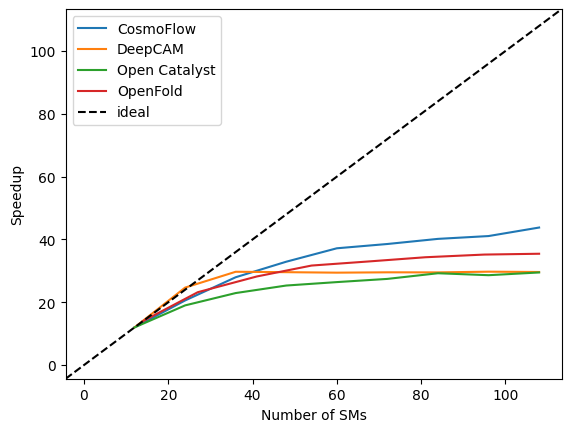

In [1]:
import numpy as np
from matplotlib import pyplot as plt

NUM_SMS = 108
LABELS = {
    'cosmoflow': 'CosmoFlow',
    'deepcam': 'DeepCAM',
    'open_catalyst': 'Open Catalyst',
    'openfold': 'OpenFold',
}

for app in LABELS:
    results = np.loadtxt(f'{app}/results.txt')
    x = results[:, 0] * NUM_SMS // 100 # Number of SMs
    y = x[0] * results[0, 1] / results[:, 1] # Speedup
    plt.plot(x, y, label=LABELS[app])
plt.axline((1, 1), slope=1, color='black', linestyle='--', label='ideal')
plt.xlabel('Number of SMs')
plt.ylabel('Speedup')
plt.ylim(plt.xlim())
plt.legend()

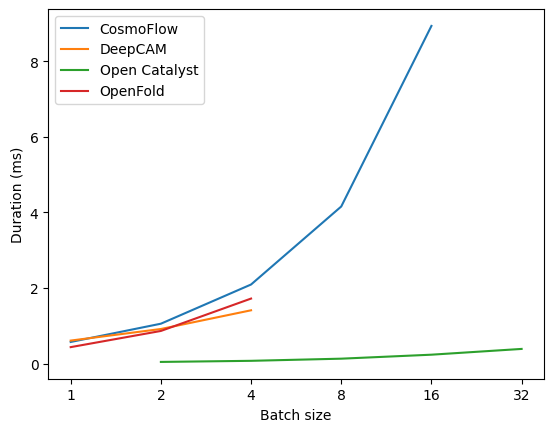

In [2]:
for app in LABELS:
    x, y = np.loadtxt(f'{app}/kernels.txt', unpack=True)
    plt.semilogx(x, y / 1000 / 1000, label=LABELS[app])
plt.xlabel('Batch size')
ticks = 2**np.arange(6)
plt.xticks([], minor=True)
plt.xticks(ticks, ticks)
plt.ylabel('Duration (ms)')
plt.legend()